In [70]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field
from typing import List,Annotated
import operator
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

load_dotenv()
import os


In [71]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(description="Final verdict on tweet quality")
    feedback: str = Field(description="One short paragraph explaining strengths and weaknesses")

In [72]:
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview",api_key=os.getenv('GEMINI_API_KEY'))
eval_llm = llm.with_structured_output(TweetEvaluation)


In [73]:
class XState(BaseModel):
    topic : str 
    tweet : str | None = None
    evaluation : Literal['approved','need_improvement'] | None = None
    feedback : str | None = None
    iteration : int = 0
    max_iteration : int 
    tweet_history : Annotated[list[str],operator.add] 

In [74]:
def genrate_tweet(state:XState):
    msgs = [
        SystemMessage(content='You are funny and clever Twitter/X influencer.'),
        HumanMessage(content=f"""
        Write a short, original and hilarious tweet on the topic : {state.topic}.

        Rules:
        - Do not use question answer format.
        - Max 200 characters.
        - Use observational humor, irony sarcasm or cultural refrences.
        - Think in meme logic, punchlines or relatable takes.
        - Use simple, day to day english.

        """)]
    
    res = llm.invoke(msgs).content[0]['text']
    return {'tweet':res,'tweet_history':[res]} 



def evaluate(state:XState):
    msgs = [
    SystemMessage(
        content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and format."
    ),
    HumanMessage(
        content=f"""
        Evaluate the following tweet:

        Tweet:
        {state.tweet}

        Criteria:
        1. Originality – Is this fresh or overused?
        2. Humor – Is it genuinely funny?
        3. Punchline – Is it short, sharp, and scroll-stopping?
        4. Virality Potential – Would people share or retweet it?
        5. Format – Is it under 280 characters and NOT Q&A or setup-punchline?

        Auto-reject if:
        - Question-answer format (e.g., "Why did...", "What happens when...")
        - Exceeds 280 characters
        - Traditional setup–punchline joke
        - Weak or generic ending

        Return ONLY valid JSON:
        {{
        "evaluation": "approved" or "need_improvement",
        "feedback": "one short paragraph"
        }}
        """
            )
        ]
    
    res = eval_llm.invoke(msgs)

    return {'evaluation':res.evaluation,'feedback':res.feedback}
    
    
    
def optimize(state: XState):
    msgs = [
        SystemMessage(
            content="You are an expert Twitter ghostwriter. You rewrite tweets to maximize humor, sharpness, and virality."
        ),
        HumanMessage(
            content=f"""
Rewrite the tweet using the feedback below.

Feedback:
{state.feedback}

Topic:
{state.topic}

Original Tweet:
{state.tweet}

Rules:
- Keep it under 200 characters
- No question-answer format
- No setup–punchline joke format
- Make it sharper, funnier, and more relatable
- Keep it punchy and scroll-stopping

Return ONLY the improved tweet.
"""
        )
    ]

    res = llm.invoke(msgs).content[0]['text']
    
    return {
        'tweet': res,   
        'iteration': state.iteration + 1,
        'tweet_history':[res]
    }


def route(state:XState):
    if state.evaluation == 'approved' or state.iteration > state.max_iteration:
        return 'approved'
    else :
        return 'need_improvement'

In [75]:
graph = StateGraph(XState)

graph.add_node('genrate_tweet',genrate_tweet)
graph.add_node('evaluate',evaluate)
graph.add_node('optimize',optimize)


graph.add_edge(START,"genrate_tweet")
graph.add_edge("genrate_tweet",'evaluate')
graph.add_conditional_edges('evaluate',route,{'approved':END,'need_improvement':'optimize'})
graph.add_edge('optimize','evaluate')


workfloe = graph.compile()

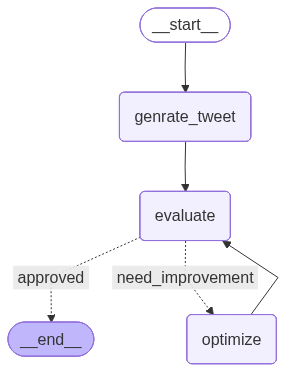

In [76]:
workfloe

In [78]:
intial_state = {
    "topic" : "Indian Railway",
    'max_iteration':5,
    'iteration':1
}

resw = workfloe.invoke(intial_state)

In [80]:
for i in resw.get('tweet_history'):
    print(i)

Having a confirmed seat in Indian Railways is just a legal permit to fight with the 4 strangers already sitting on it. ‘Thoda adjust karlo’ is the only law that actually works. 🚂💀
An Indian Railways ticket isn’t a seat; it’s a formal invitation to engage in hand-to-hand combat with a family that treats your berth like ancestral property.
